In [1]:
import numpy as np

In [18]:
# ============================================================
# 1. MANUAL CONTENT-GROUP MAPPING
# ============================================================

# Group 0 = Questions
# Group 1 = Japanese text
# Group 2 = English text

manual_cluster_map = pd.DataFrame({
    "element": [
        "Q1 - What was Mrs. Weston worried about?",
        "Q2 - Why was Gloria sad?",
        "Q3 - What is the first law of Robotics?",
        "Q4 - What happens to Robbie at the end?",

        "1🟦【導入部：ロボット「ロビー」とグロリア】",
        "2🟧【母親の不安と別れ】",
        "3🟩【喪失による喪失感】",
        "4🟥【博物館での出来事：誤解とトラブル】",
        "5🟨【再会：ロボット工場での奇跡】",
        "6🟫【対話：両親の意見の対立】",
        "7🟦【結末：信頼と共生】",

        "1🟦 [Introduction: the robot 'Robbie' and Gloria]",
        "2🟧 [The mother's anxieties and the separation]",
        "3🟩 [Grief after the loss]",
        "4🟥 [At the museum: misunderstanding and trouble]",
        "5🟨 [Reunion: a near-miracle at the robot factory]",
        "6🟫 [Dialogue: the parents’ disagreement]",
        "7🟦 [Ending: trust and coexistence]"
    ],

    "cluster": [
        # Questions
        0, 0, 0, 0,

        # Japanese
        1, 1, 1, 1, 1, 1, 1,

        # English
        2, 2, 2, 2, 2, 2, 2
    ]
})

print(manual_cluster_map)

                                              element  cluster
0            Q1 - What was Mrs. Weston worried about?        0
1                            Q2 - Why was Gloria sad?        0
2             Q3 - What is the first law of Robotics?        0
3             Q4 - What happens to Robbie at the end?        0
4                              1🟦【導入部：ロボット「ロビー」とグロリア】        1
5                                        2🟧【母親の不安と別れ】        1
6                                        3🟩【喪失による喪失感】        1
7                                4🟥【博物館での出来事：誤解とトラブル】        1
8                                   5🟨【再会：ロボット工場での奇跡】        1
9                                     6🟫【対話：両親の意見の対立】        1
10                                       7🟦【結末：信頼と共生】        1
11   1🟦 [Introduction: the robot 'Robbie' and Gloria]        2
12     2🟧 [The mother's anxieties and the separation]        2
13                          3🟩 [Grief after the loss]        2
14   4🟥 [At the museum: misunderstanding and trouble]  

In [20]:
gaze_episodes = pd.read_csv("gaze_episodes_final.csv")

In [21]:
# ============================================================
# 1. CREATE MANUAL CONTENT GROUPS
# ============================================================

def is_question(element):
    return str(element).startswith("Q")


def is_japanese(element):
    text = str(element)

    return any(
        "\u3040" <= char <= "\u30ff"
        or "\u3400" <= char <= "\u9fff"
        for char in text
    )


def assign_manual_cluster(element):

    if is_question(element):
        return 0

    elif is_japanese(element):
        return 1

    else:
        return 2


manual_cluster_map = (
    gaze_episodes[["aoi"]]
    .drop_duplicates()
    .rename(columns={"aoi": "element"})
)

manual_cluster_map["cluster"] = (
    manual_cluster_map["element"]
    .apply(assign_manual_cluster)
)

print("\nMANUAL CONTENT GROUPS")
print("=" * 80)
print(
    manual_cluster_map
    .sort_values(["cluster", "element"])
    .to_string(index=False)
)


MANUAL CONTENT GROUPS
                                          element  cluster
         Q1 - What was Mrs. Weston worried about?        0
                         Q2 - Why was Gloria sad?        0
          Q3 - What is the first law of Robotics?        0
          Q4 - What happens to Robbie at the end?        0
                           1🟦【導入部：ロボット「ロビー」とグロリア】        1
                                     2🟧【母親の不安と別れ】        1
                                     3🟩【喪失による喪失感】        1
                             4🟥【博物館での出来事：誤解とトラブル】        1
                                5🟨【再会：ロボット工場での奇跡】        1
                                  6🟫【対話：両親の意見の対立】        1
                                     7🟦【結末：信頼と共生】        1
 1🟦 [Introduction: the robot 'Robbie' and Gloria]        2
   2🟧 [The mother's anxieties and the separation]        2
                        3🟩 [Grief after the loss]        2
 4🟥 [At the museum: misunderstanding and trouble]        2
5🟨 [Reunion: a near-miracle at th

In [22]:
# ============================================================
# 2. MAP MANUAL GROUPS TO GAZE EPISODES
# ============================================================

gaze_for_spm = (
    gaze_episodes
    .rename(columns={"aoi": "element"})
    .merge(
        manual_cluster_map,
        on="element",
        how="left"
    )
)

gaze_for_spm["verb"] = "Gazed"

gaze_for_spm["event_timestamp"] = pd.to_datetime(
    gaze_for_spm["gaze_start"],
    errors="coerce",
    utc=True
)

gaze_for_spm["gaze_cluster_activity"] = (
    "Gazed element from Cluster "
    + gaze_for_spm["cluster"]
        .astype("Int64")
        .astype(str)
)

gaze_for_spm["cluster_activity"] = (
    "Gazed at element from Cluster "
    + gaze_for_spm["cluster"]
        .astype("Int64")
        .astype(str)
)

gaze_for_spm["element_activity"] = (
    "Gazed "
    + gaze_for_spm["element"].astype(str)
)

In [23]:
# ============================================================
# 3. MAP MANUAL GROUPS TO INTERACTION DATA
# ============================================================

interaction_df = pd.read_csv("robo.csv")

interaction = interaction_df[
    interaction_df["element"].notna()
].copy()

interaction = interaction.merge(
    manual_cluster_map,
    on="element",
    how="left"
)

interaction["event_timestamp"] = pd.to_datetime(
    interaction["timeStamp"],
    errors="coerce",
    utc=True
)

interaction["verb"] = (
    interaction["verb"].astype(str)
)

interaction["cluster_activity"] = (
    interaction["verb"]
    + " element from Cluster "
    + interaction["cluster"]
        .astype("Int64")
        .astype(str)
)

interaction["element_activity"] = (
    interaction["verb"]
    + " "
    + interaction["element"].astype(str)
)

interaction["non_gaze_cluster_activity"] = (
    "Non-Gaze Interaction with element from Cluster "
    + interaction["cluster"]
        .astype("Int64")
        .astype(str)
)

In [24]:
# ============================================================
# 4. COMBINED GAZE + INTERACTION DATA
# ============================================================

gaze_interaction_manual = pd.concat(
    [
        gaze_for_spm,
        interaction
    ],
    ignore_index=True,
    sort=False
)

gaze_interaction_manual[
    "interaction_cluster_activity"
] = (
    "Interacted with element from Cluster "
    + gaze_interaction_manual["cluster"]
        .astype("Int64")
        .astype(str)
)

gaze_interaction_manual = (
    gaze_interaction_manual
    .sort_values(
        ["user_id", "event_timestamp"]
    )
    .reset_index(drop=True)
)

In [29]:
# ============================================================
# 4. COMBINED GAZE + INTERACTION DATA
# ============================================================

gaze_interaction_manual = pd.concat(
    [
        gaze_for_spm,
        interaction
    ],
    ignore_index=True,
    sort=False
)

gaze_interaction_manual[
    "interaction_cluster_activity"
] = (
    "Interacted with element from Cluster "
    + gaze_interaction_manual["cluster"]
        .astype("Int64")
        .astype(str)
)

gaze_interaction_manual = (
    gaze_interaction_manual
    .sort_values(
        ["user_id", "event_timestamp"]
    )
    .reset_index(drop=True)
)

# Keep exactly the same columns and order
gaze_interaction_manual = gaze_interaction_manual[
    [
        "user_id",
        "event_timestamp",
        "verb",
        "element",
        "elementType",
        "cluster_activity",
        "element_activity",
        "interaction_cluster_activity",
        "gaze_cluster_activity"
    ]
]
gaze_interaction_manual.to_csv(
    "gaze_interaction_spm_manual_groups.csv",
    index=False
)

In [26]:
# ============================================================
# 5. NON-GAZE INTERACTION DATA
# ============================================================

interaction_only_manual = (
    interaction
    .sort_values(
        ["user", "event_timestamp"]
    )
    .reset_index(drop=True)
)

interaction_only_manual["user_id"] = (
    interaction_only_manual["user"]
)

interaction_only_manual = (
    interaction_only_manual
    .sort_values(
        ["user_id", "event_timestamp"]
    )
    .reset_index(drop=True)
)

In [27]:
# ============================================================
# 5. NON-GAZE INTERACTION DATA
# ============================================================

interaction_only_manual = (
    interaction
    .sort_values(
        ["user", "event_timestamp"]
    )
    .reset_index(drop=True)
)

interaction_only_manual["user_id"] = (
    interaction_only_manual["user"]
)

interaction_only_manual = (
    interaction_only_manual
    .sort_values(
        ["user_id", "event_timestamp"]
    )
    .reset_index(drop=True)
)

In [28]:
# ============================================================
# 6. SAVE MANUAL-GROUP DATA
# ============================================================

manual_cluster_map.to_csv(
    "manual_content_groups.csv",
    index=False
)

gaze_interaction_manual.to_csv(
    "gaze_interaction_spm_manual_groups.csv",
    index=False
)

interaction_only_manual.to_csv(
    "interaction_spm_manual_groups.csv",
    index=False
)

print("\nFiles created:")
print("  manual_content_groups.csv")
print("  gaze_interaction_spm_manual_groups.csv")
print("  interaction_spm_manual_groups.csv")


Files created:
  manual_content_groups.csv
  gaze_interaction_spm_manual_groups.csv
  interaction_spm_manual_groups.csv


In [30]:
manual_df = pd.read_csv("manual_matrix.csv")
manual_df

,From \ To,Interacted with element from Cluster 0,Interacted with element from Cluster 1,Interacted with element from Cluster 2
0,Interacted with element from Cluster 0,0.751,0.085,0.164
1,Interacted with element from Cluster 1,0.073,0.634,0.293
2,Interacted with element from Cluster 2,0.084,0.178,0.738


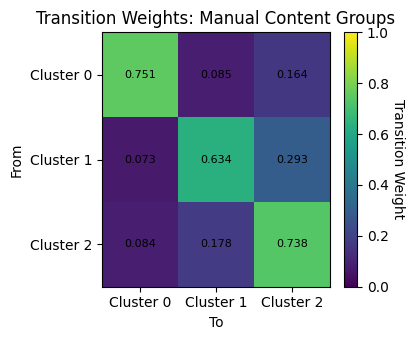

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LOAD MANUAL TRANSITION MATRIX
# ============================================================

manual_df = pd.read_csv(
    "manual_matrix.csv",
    index_col=0
)

manual_df = manual_df.apply(
    pd.to_numeric,
    errors="coerce"
)

# Use Cluster labels for rows and columns
manual_df.index = [
    "Cluster 0",
    "Cluster 1",
    "Cluster 2"
]

manual_df.columns = [
    "Cluster 0",
    "Cluster 1",
    "Cluster 2"
]


# ============================================================
# CREATE HEATMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(4.2, 3.5)
)

im = ax.imshow(
    manual_df.values,
    vmin=0,
    vmax=1,
    aspect="auto"
)


# ============================================================
# AXIS LABELS
# ============================================================

ax.set_xticks(range(3))
ax.set_yticks(range(3))

ax.set_xticklabels(
    manual_df.columns
)

ax.set_yticklabels(
    manual_df.index
)

ax.set_xlabel("To")
ax.set_ylabel("From")

ax.set_title(
    "Transition Weights: Manual Content Groups"
)


# ============================================================
# ADD VALUES TO CELLS
# ============================================================

for i in range(manual_df.shape[0]):
    for j in range(manual_df.shape[1]):

        value = manual_df.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.3f}",
            ha="center",
            va="center",
            fontsize=8
        )


# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Transition Weight",
    rotation=270,
    labelpad=12
)


# ============================================================
# SAVE SVG
# ============================================================

fig.tight_layout()

fig.savefig(
    "manual_transition_weights.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

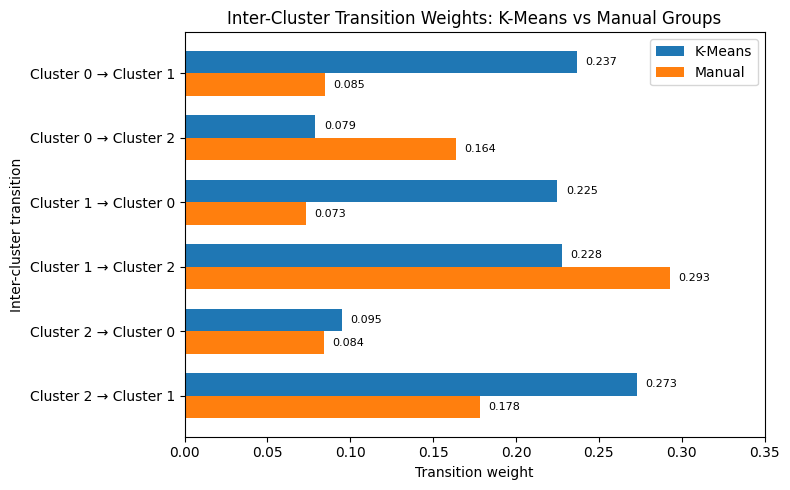

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# INTER-CLUSTER TRANSITION WEIGHTS
# ============================================================

data = {
    "Transition": [
        "Cluster 0 → Cluster 1",
        "Cluster 0 → Cluster 2",
        "Cluster 1 → Cluster 0",
        "Cluster 1 → Cluster 2",
        "Cluster 2 → Cluster 0",
        "Cluster 2 → Cluster 1"
    ],

    "K-Means": [
        0.237,
        0.079,
        0.225,
        0.228,
        0.095,
        0.273
    ],

    "Manual": [
        0.085,
        0.164,
        0.073,
        0.293,
        0.084,
        0.178
    ]
}

comparison_df = pd.DataFrame(data)


# ============================================================
# GROUPED HORIZONTAL BAR CHART
# ============================================================

y = np.arange(len(comparison_df))
bar_height = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    y - bar_height / 2,
    comparison_df["K-Means"],
    height=bar_height,
    label="K-Means"
)

ax.barh(
    y + bar_height / 2,
    comparison_df["Manual"],
    height=bar_height,
    label="Manual"
)

ax.set_yticks(y)
ax.set_yticklabels(comparison_df["Transition"])

ax.set_xlabel("Transition weight")
ax.set_ylabel("Inter-cluster transition")

ax.set_title(
    "Inter-Cluster Transition Weights: K-Means vs Manual Groups"
)

ax.set_xlim(0, 0.35)

ax.legend()

ax.invert_yaxis()


# ============================================================
# ADD VALUES
# ============================================================

for i, value in enumerate(comparison_df["K-Means"]):
    ax.text(
        value + 0.005,
        i - bar_height / 2,
        f"{value:.3f}",
        va="center",
        fontsize=8
    )

for i, value in enumerate(comparison_df["Manual"]):
    ax.text(
        value + 0.005,
        i + bar_height / 2,
        f"{value:.3f}",
        va="center",
        fontsize=8
    )


# ============================================================
# SAVE
# ============================================================

fig.tight_layout()

fig.savefig(
    "inter_cluster_transition_weights_comparison.svg",
    format="svg",
    bbox_inches="tight"
)

fig.savefig(
    "inter_cluster_transition_weights_comparison.svg",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)